# Model 4 — Prior Probability Correction

**문제**: Train prior(35% 1) ≠ Test prior(~49% 1) → label shift

**핵심 전략**
1. **Prior Correction**: 베이즈 정리로 확률을 test 분포에 맞게 보정 (수학적으로 최적)
2. **Test-prior class weights**: 학습 단계에서 test 비율을 반영한 가중치
3. **SMOTE 50:50**: 학습 데이터 자체를 test 분포에 맞게 균등화

세 전략 모두 적용 후 threshold=0.5 → 예측 1 비율이 ~0.488에 수렴해야 함

산출물: `answer4.csv` · `subfinal4.csv`

In [1]:
import subprocess, sys
def pip_install(pkg, imp=None):
    try: __import__(imp or pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

pip_install('xgboost'); pip_install('lightgbm')
pip_install('imbalanced-learn','imblearn'); pip_install('optuna')
print('준비 완료')

준비 완료


c:\Users\oh\Documents\GitHub\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120

from sklearn.base            import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import (RandomForestClassifier, ExtraTreesClassifier,
                                     HistGradientBoostingClassifier, VotingClassifier)
from sklearn.neural_network  import MLPClassifier
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.preprocessing   import OrdinalEncoder, StandardScaler
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.metrics         import (roc_auc_score, accuracy_score,
                                     balanced_accuracy_score, f1_score)
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE

try: from xgboost  import XGBClassifier;  HAS_XGB  = True
except ImportError: HAS_XGB = False
try: from lightgbm import LGBMClassifier; HAS_LGBM = True
except ImportError: HAS_LGBM = False
try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError: HAS_OPTUNA = False

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'XGB={HAS_XGB}  LGBM={HAS_LGBM}  Optuna={HAS_OPTUNA}')

XGB=True  LGBM=True  Optuna=True


## 1. 데이터 로드 & Prior 상수 정의

In [3]:
if os.path.exists('train.csv'):
    train = pd.read_csv('train.csv')
    test  = pd.read_csv('test.csv') if os.path.exists('test.csv') else None
else:
    import kagglehub
    path  = kagglehub.competition_download('ssu-problem-solving-2026')
    train = pd.read_csv(os.path.join(path, 'train.csv'))
    test  = pd.read_csv(os.path.join(path, 'test.csv'))

# ── Prior 상수 (실측값 기반) ──────────────────────────────────
P_TRAIN_1  = train['target'].mean()          # 0.3432  (train에서 직접 계산)
P_TRAIN_0  = 1 - P_TRAIN_1
P_TEST_1   = 1 - 0.51217                     # 0.48783 (all-zeros public score로 역산)
P_TEST_0   = 1 - P_TEST_1

# Prior correction factor: odds ratio 보정값
CORRECTION = (P_TEST_1 / P_TEST_0) / (P_TRAIN_1 / P_TRAIN_0)

# threshold=0.5 after correction ↔ raw probability 기준 effective threshold
THRESH_RAW = 1 / (1 + CORRECTION)

# Test-prior 보정 class weights: P_test/P_train
W1 = P_TEST_1 / P_TRAIN_1   # 1 클래스 가중치
W0 = P_TEST_0 / P_TRAIN_0   # 0 클래스 가중치
CLASS_W = {0: W0, 1: W1}

print(f'Train prior:  P(0)={P_TRAIN_0:.4f}  P(1)={P_TRAIN_1:.4f}')
print(f'Test prior:   P(0)={P_TEST_0:.4f}  P(1)={P_TEST_1:.4f}')
print(f'Correction factor: {CORRECTION:.4f}')
print(f'Effective raw threshold: {THRESH_RAW:.4f}  (= predict 1 if P_model(1|x) > {THRESH_RAW:.3f})')
print(f'Test-prior class weights: {{0: {W0:.3f}, 1: {W1:.3f}}}')
print(f'\ntrain={train.shape}  test={test.shape if test is not None else None}')

Train prior:  P(0)=0.6568  P(1)=0.3432
Test prior:   P(0)=0.5122  P(1)=0.4878
Correction factor: 1.8228
Effective raw threshold: 0.3543  (= predict 1 if P_model(1|x) > 0.354)
Test-prior class weights: {0: 0.780, 1: 1.421}

train=(10000, 40)  test=(2000, 39)


## 2. Feature 정의 & 상호작용 Feature Engineering

In [4]:
# Adversarial validation 기반: 전이 불가 feature 제거, 전이 가능 feature만 사용
DROP  = ['id', 'feat_08', 'feat_09', 'feat_14', 'feat_24', 'feat_34', 'feat_38']  # adv_auc~=1.0
CORE6 = ['feat_05', 'feat_31', 'feat_07', 'feat_02', 'feat_36']           # TRANSFER_CORE
CORE7 = CORE6 + ['feat_01']   # TRANSFER_PLUS01: P(y|x) 보존 확인됨
ALL34 = [c for c in train.columns if c not in DROP + ['target']]  # ALL_TRANSFER (32개)

CORE6_NUM = ['feat_01', 'feat_02', 'feat_05', 'feat_07']   # 수치형만

def add_interactions(df, num_feats=CORE6_NUM):
    """CORE6 수치형 feature 간 곱 상호작용항 추가."""
    df = df.copy()
    for i, f1 in enumerate(num_feats):
        for f2 in num_feats[i+1:]:
            df[f'{f1}_x_{f2}'] = df[f1] * df[f2]
    return df

train_fe = add_interactions(train)
test_fe  = add_interactions(test) if test is not None else None

INTERACT_COLS = [c for c in train_fe.columns if '_x_' in c]
ALL34_FE = ALL34 + INTERACT_COLS
CORE7_FE = CORE7 + INTERACT_COLS

TIERS = {'CORE7_FE': CORE7_FE, 'ALL34_FE': ALL34_FE, 'CORE7': CORE7, 'ALL34': ALL34}

def get_cat(cols, df=train_fe): return [c for c in cols if df[c].dtype == object]
def get_num(cols, df=train_fe): return [c for c in cols if df[c].dtype != object]

print(f'상호작용 feature {len(INTERACT_COLS)}개: {INTERACT_COLS}')
print(f'Tiers: {[(k,len(v)) for k,v in TIERS.items()]}')

상호작용 feature 6개: ['feat_01_x_feat_02', 'feat_01_x_feat_05', 'feat_01_x_feat_07', 'feat_02_x_feat_05', 'feat_02_x_feat_07', 'feat_05_x_feat_07']
Tiers: [('CORE7_FE', 12), ('ALL34_FE', 38), ('CORE7', 6), ('ALL34', 32)]


## 3. Prior Correction 클래스 & 공통 유틸

In [5]:
class PriorCorrectedPipe(BaseEstimator, ClassifierMixin):
    """
    어떤 파이프라인이든 감싸서 predict_proba 출력에 prior correction을 적용.
    AUC는 correction 전후 동일(단조 변환). threshold=0.5 기준 예측 분포가 달라짐.
    """
    def __init__(self, pipe, correction=CORRECTION):
        self.pipe = pipe
        self.correction = correction

    def fit(self, X, y):
        self.pipe_ = clone(self.pipe)
        self.pipe_.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        p1 = self.pipe_.predict_proba(X)[:, 1]
        eps = 1e-9
        odds = p1 / (1 - p1 + eps)
        odds_c = odds * self.correction
        p1_c = odds_c / (1 + odds_c)
        return np.column_stack([1 - p1_c, p1_c])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def build_preprocessor(feature_cols, scale=False, df=train_fe):
    cat = get_cat(feature_cols, df)
    num = get_num(feature_cols, df)
    tr  = []
    if cat: tr.append(('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                                              unknown_value=-1), cat))
    if num: tr.append(('num', StandardScaler() if scale else 'passthrough', num))
    return ColumnTransformer(tr, verbose_feature_names_out=False)

def build_pipe(feature_cols, clf, scale=False, smote=False, smote_ratio=1.0):
    prep  = build_preprocessor(feature_cols, scale)
    steps = [('prep', prep)]
    if smote:
        steps.append(('smote', SMOTE(sampling_strategy=smote_ratio,
                                     random_state=RANDOM_STATE)))
        steps.append(('clf', clf))
        return ImbPipeline(steps)
    steps.append(('clf', clf))
    return Pipeline(steps)

def evaluate_oof(pipe, feature_cols, correct=True, df=train_fe):
    """OOF 확률 → (필요시 prior correction) → 지표 계산."""
    X, y = df[feature_cols], train['target']
    p1 = cross_val_predict(pipe, X, y, cv=CV, method='predict_proba', n_jobs=-1)[:, 1]
    if correct:
        eps = 1e-9
        odds = p1 / (1 - p1 + eps)
        p1 = (odds * CORRECTION) / (1 + odds * CORRECTION)
    binary = (p1 >= 0.5).astype(int)
    return {
        'auc':    roc_auc_score(y, p1),
        'acc':    accuracy_score(y, binary),
        'bacc':   balanced_accuracy_score(y, binary),
        'ratio1': binary.mean(),
    }

def show_res(name, r):
    ratio_ok = '✓' if 0.40 < r['ratio1'] < 0.57 else '⚠'
    print(f"{name:<38} AUC={r['auc']:.4f}  Acc={r['acc']:.4f}  "
          f"BalAcc={r['bacc']:.4f}  1-ratio={r['ratio1']:.3f}{ratio_ok}")

print('PriorCorrectedPipe & 유틸 정의 완료')
print(f'Prior correction 후 예측 1 비율 목표: ~{P_TEST_1:.3f}')

PriorCorrectedPipe & 유틸 정의 완료
Prior correction 후 예측 1 비율 목표: ~0.488


## 4. Strategy A — Test-Prior Class Weights (학습 단계 보정)

In [6]:
# class_weight = {0: W0, 1: W1} → 학습 손실에서 test prior 반영
# 이 가중치가 적용된 모델 + post-hoc prior correction 이중 적용

spw_test = P_TEST_0 / P_TEST_1   # XGB용: scale_pos_weight ≈ 1.049 (거의 균등)

strat_a_models = {
    'LR(test-prior-w)':    (LogisticRegression(C=1.0, class_weight=CLASS_W,
                                max_iter=1000, random_state=RANDOM_STATE), True),
    'RF(test-prior-w)':    (RandomForestClassifier(n_estimators=400, class_weight=CLASS_W,
                                n_jobs=-1, random_state=RANDOM_STATE), False),
    'ET(test-prior-w)':    (ExtraTreesClassifier(n_estimators=400, class_weight=CLASS_W,
                                n_jobs=-1, random_state=RANDOM_STATE), False),
    'HistGB(test-prior-w)':(HistGradientBoostingClassifier(max_iter=400,
                                class_weight=CLASS_W, random_state=RANDOM_STATE), False),
    'MLP(test-prior-w)':   (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                                early_stopping=True, random_state=RANDOM_STATE), True),
}
if HAS_XGB:
    strat_a_models['XGB(test-prior-w)'] = (XGBClassifier(
        n_estimators=400, scale_pos_weight=spw_test, learning_rate=0.05, max_depth=5,
        n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), False)
if HAS_LGBM:
    strat_a_models['LGBM(test-prior-w)'] = (LGBMClassifier(
        n_estimators=400, class_weight=CLASS_W, learning_rate=0.05, num_leaves=31,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1), False)

results_a = {}
print('Strategy A: Test-Prior Class Weights + Prior Correction')
print(f"{'Model':<38} {'AUC':>7} {'Acc':>7} {'BalAcc':>8} {'1-ratio':>9}")
print('-' * 72)

best_tier_a = CORE7_FE   # CORE7 + interactions (model3 best tier 기반)

for name, (clf, need_scale) in strat_a_models.items():
    pipe = build_pipe(best_tier_a, clf, scale=need_scale)
    r    = evaluate_oof(pipe, best_tier_a, correct=True)
    results_a[name] = r
    show_res(name, r)

Strategy A: Test-Prior Class Weights + Prior Correction
Model                                      AUC     Acc   BalAcc   1-ratio
------------------------------------------------------------------------
LR(test-prior-w)                       AUC=0.6662  Acc=0.4262  BalAcc=0.5305  1-ratio=0.823⚠
RF(test-prior-w)                       AUC=0.6550  Acc=0.6718  BalAcc=0.6316  1-ratio=0.331⚠
ET(test-prior-w)                       AUC=0.6497  Acc=0.6473  BalAcc=0.6167  1-ratio=0.366⚠
HistGB(test-prior-w)                   AUC=0.6518  Acc=0.6052  BalAcc=0.6020  1-ratio=0.458✓
MLP(test-prior-w)                      AUC=0.6631  Acc=0.7060  BalAcc=0.6484  1-ratio=0.270⚠
XGB(test-prior-w)                      AUC=0.6632  Acc=0.6863  BalAcc=0.6375  1-ratio=0.301⚠
LGBM(test-prior-w)                     AUC=0.6549  Acc=0.5743  BalAcc=0.5892  1-ratio=0.519✓


## 5. Strategy B — SMOTE to 50:50 (학습 데이터 균등화)

In [7]:
# SMOTE로 학습 데이터를 50:50으로 균등화 → prior correction 없이도 예측 분포 균등
# (단, SMOTE 후에도 prior correction 적용 시 가장 좋음)

# AUC 상위 3개 모델에 대해 SMOTE 비교
top3_a = sorted(results_a, key=lambda k: results_a[k]['auc'], reverse=True)[:3]
print(f'SMOTE 비교 대상 (AUC 상위 3): {top3_a}\n')

results_b = {}
print('Strategy B: SMOTE 50:50 + Prior Correction')
print(f"{'Model':<42} {'AUC':>7} {'Acc':>7} {'BalAcc':>8} {'1-ratio':>9}")
print('-' * 76)

for name in top3_a:
    clf, need_scale = strat_a_models[name]
    # SMOTE 버전 (no class_weight → SMOTE가 균형을 담당)
    clf_no_w = clf.__class__(**{k: (None if k == 'class_weight'
                                    else (1.0 if k == 'scale_pos_weight' else v))
                                for k, v in clf.get_params().items()})
    pipe_smote = build_pipe(best_tier_a, clf_no_w, scale=need_scale,
                            smote=True, smote_ratio=1.0)
    r = evaluate_oof(pipe_smote, best_tier_a, correct=True)
    key = name.replace('test-prior-w', 'SMOTE')
    results_b[key] = r
    show_res(key, r)
    delta = r['auc'] - results_a[name]['auc']
    print(f"  vs test-prior-w: AUC {delta:+.4f}")

SMOTE 비교 대상 (AUC 상위 3): ['LR(test-prior-w)', 'XGB(test-prior-w)', 'MLP(test-prior-w)']

Strategy B: SMOTE 50:50 + Prior Correction
Model                                          AUC     Acc   BalAcc   1-ratio
----------------------------------------------------------------------------
LR(SMOTE)                              AUC=0.6659  Acc=0.4056  BalAcc=0.5234  1-ratio=0.868⚠
  vs test-prior-w: AUC -0.0003
XGB(SMOTE)                             AUC=0.6588  Acc=0.5411  BalAcc=0.5785  1-ratio=0.595⚠
  vs test-prior-w: AUC -0.0043
MLP(SMOTE)                             AUC=0.6599  Acc=0.4555  BalAcc=0.5430  1-ratio=0.765⚠
  vs test-prior-w: AUC -0.0032


## 6. Strategy C — Prior Correction Only (raw balanced 모델 후처리)

In [8]:
# class_weight='balanced' 모델 + 후처리 prior correction만
# (model3 챔피언과 동일 모델, correction만 추가)

results_c = {}
print('Strategy C: class_weight=balanced + Prior Correction (post-hoc)')
print(f"{'Model':<42} {'AUC':>7} {'Acc':>7} {'BalAcc':>8} {'1-ratio':>9}")
print('-' * 76)

for name in top3_a:
    clf, need_scale = strat_a_models[name]
    # balanced 버전으로 교체
    params = clf.get_params()
    try:
        clf_bal = clf.__class__(**{k: ('balanced' if k == 'class_weight'
                                       else (CORRECTION if k == 'scale_pos_weight' else v))
                                   for k, v in params.items()})
    except Exception:
        clf_bal = clf.__class__(**{k: v for k, v in params.items()})
    pipe = build_pipe(best_tier_a, clf_bal, scale=need_scale)
    r = evaluate_oof(pipe, best_tier_a, correct=True)
    key = name.replace('test-prior-w', 'bal+correct')
    results_c[key] = r
    show_res(key, r)

Strategy C: class_weight=balanced + Prior Correction (post-hoc)
Model                                          AUC     Acc   BalAcc   1-ratio
----------------------------------------------------------------------------
LR(bal+correct)                        AUC=0.6663  Acc=0.3957  BalAcc=0.5177  1-ratio=0.883⚠
XGB(bal+correct)                       AUC=0.6615  Acc=0.5469  BalAcc=0.5808  1-ratio=0.583⚠
MLP(bal+correct)                       AUC=0.6631  Acc=0.7060  BalAcc=0.6484  1-ratio=0.270⚠


## 7. 전략 통합 비교 & Best 조합 선택

            Strategy    AUC    Acc  BalAcc  1-ratio  ratio_err
     LR(bal+correct) 0.6663 0.3957  0.5177   0.8835     0.3957
    LR(test-prior-w) 0.6662 0.4262  0.5305   0.8230     0.3352
           LR(SMOTE) 0.6659 0.4056  0.5234   0.8682     0.3804
   XGB(test-prior-w) 0.6632 0.6863  0.6375   0.3013     0.1865
   MLP(test-prior-w) 0.6631 0.7060  0.6484   0.2698     0.2180
    MLP(bal+correct) 0.6631 0.7060  0.6484   0.2698     0.2180
    XGB(bal+correct) 0.6615 0.5469  0.5808   0.5827     0.0949
          MLP(SMOTE) 0.6599 0.4555  0.5430   0.7655     0.2777
          XGB(SMOTE) 0.6588 0.5411  0.5785   0.5945     0.1067
    RF(test-prior-w) 0.6550 0.6718  0.6316   0.3306     0.1572
  LGBM(test-prior-w) 0.6549 0.5743  0.5892   0.5195     0.0317
HistGB(test-prior-w) 0.6518 0.6052  0.6020   0.4578     0.0300
    ET(test-prior-w) 0.6497 0.6473  0.6167   0.3659     0.1219

Champion: LR(bal+correct)  (AUC=0.6663)


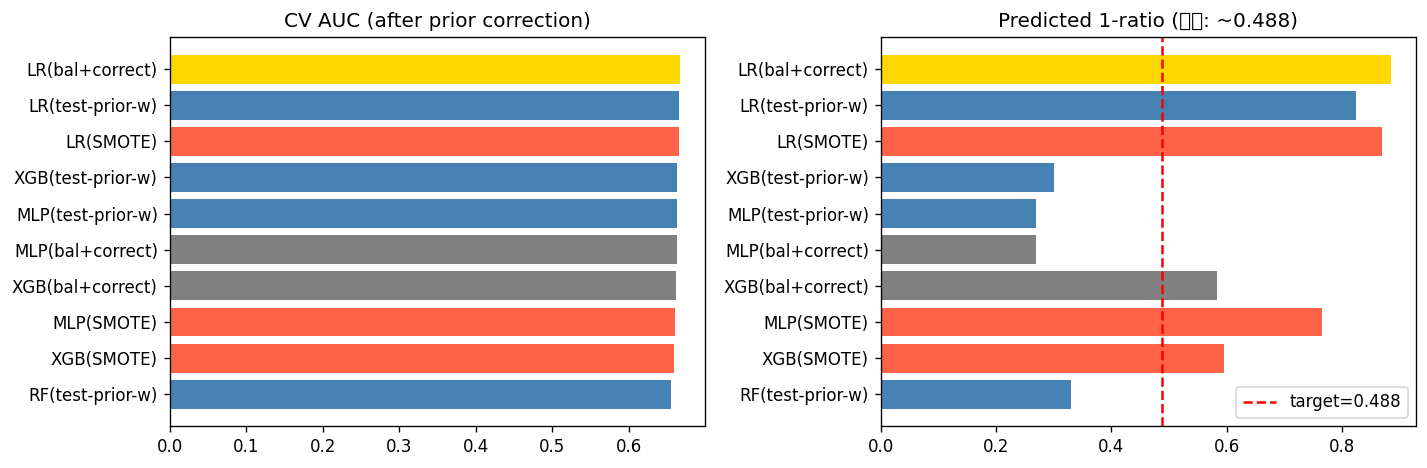

In [9]:
all_res = {**results_a, **results_b, **results_c}

rows = [{'Strategy': k,
         'AUC': v['auc'], 'Acc': v['acc'],
         'BalAcc': v['bacc'], '1-ratio': v['ratio1'],
         'ratio_err': abs(v['ratio1'] - P_TEST_1)}
        for k, v in all_res.items()]
cdf = (pd.DataFrame(rows)
       .sort_values('AUC', ascending=False)
       .reset_index(drop=True))

print(cdf.to_string(index=False, float_format='{:.4f}'.format))

# AUC 기준 champion
champ_key = cdf.iloc[0]['Strategy']
champ_auc = cdf.iloc[0]['AUC']
print(f'\nChampion: {champ_key}  (AUC={champ_auc:.4f})')

# 시각화
top_n = min(10, len(cdf))
top   = cdf.head(top_n)
colors = ['gold' if s == champ_key else
          'tomato' if 'SMOTE' in s else
          'steelblue' if 'test-prior' in s else 'gray'
          for s in top['Strategy']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(top['Strategy'][::-1], top['AUC'][::-1], color=colors[::-1])
axes[0].set_title('CV AUC (after prior correction)')
axes[1].barh(top['Strategy'][::-1], top['1-ratio'][::-1], color=colors[::-1])
axes[1].axvline(P_TEST_1, color='red', linestyle='--', label=f'target={P_TEST_1:.3f}')
axes[1].set_title('Predicted 1-ratio (목표: ~0.488)')
axes[1].legend()
plt.tight_layout()
plt.savefig('model4_strategy_compare.png', bbox_inches='tight')
plt.show()

## 8. Optuna 하이퍼파라미터 튜닝

In [10]:
# Champion 모델명에서 base 모델 타입 파악
def detect_model_type(name):
    name = name.upper()
    if 'LGBM' in name: return 'lgbm'
    if 'XGB'  in name: return 'xgb'
    if 'HISTG' in name or 'HGB' in name: return 'histgb'
    if 'ET'   in name: return 'et'
    if 'RF'   in name: return 'rf'
    if 'MLP'  in name: return 'mlp'
    return 'lr'

use_smote      = 'SMOTE' in champ_key
use_bal_only   = 'bal+correct' in champ_key
model_type     = detect_model_type(champ_key)
print(f'튜닝 대상: {model_type}  SMOTE={use_smote}  balanced_only={use_bal_only}')

튜닝 대상: lr  SMOTE=False  balanced_only=True


In [11]:
def make_clf(trial, mtype):
    if mtype == 'lr':
        return LogisticRegression(
            C=trial.suggest_float('C', 1e-3, 10, log=True),
            class_weight=CLASS_W, max_iter=1000, random_state=RANDOM_STATE), True
    elif mtype == 'rf':
        return RandomForestClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_categorical('max_d', [None, 10, 20, 30]),
            min_samples_leaf=trial.suggest_int('leaf', 1, 20),
            max_features=trial.suggest_categorical('mf', ['sqrt', 'log2', 0.4, 0.6]),
            class_weight=CLASS_W, n_jobs=-1, random_state=RANDOM_STATE), False
    elif mtype == 'et':
        return ExtraTreesClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_categorical('max_d', [None, 10, 20, 30]),
            min_samples_leaf=trial.suggest_int('leaf', 1, 10),
            max_features=trial.suggest_categorical('mf', ['sqrt', 'log2', 0.4, 0.6]),
            class_weight=CLASS_W, n_jobs=-1, random_state=RANDOM_STATE), False
    elif mtype == 'histgb':
        return HistGradientBoostingClassifier(
            max_iter=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_categorical('max_d', [None, 4, 6, 8, 10]),
            learning_rate=trial.suggest_float('lr', 0.005, 0.3, log=True),
            min_samples_leaf=trial.suggest_int('leaf', 5, 60),
            l2_regularization=trial.suggest_float('l2', 0.0, 3.0),
            class_weight=CLASS_W, random_state=RANDOM_STATE), False
    elif mtype == 'xgb' and HAS_XGB:
        return XGBClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            max_depth=trial.suggest_int('max_d', 3, 9),
            learning_rate=trial.suggest_float('lr', 0.005, 0.3, log=True),
            subsample=trial.suggest_float('sub', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('col', 0.5, 1.0),
            reg_alpha=trial.suggest_float('alpha', 0, 3.0),
            reg_lambda=trial.suggest_float('lam', 0.5, 6.0),
            scale_pos_weight=spw_test,
            n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), False
    elif mtype == 'lgbm' and HAS_LGBM:
        return LGBMClassifier(
            n_estimators=trial.suggest_int('n_est', 200, 800, step=100),
            num_leaves=trial.suggest_int('leaves', 15, 127),
            learning_rate=trial.suggest_float('lr', 0.005, 0.3, log=True),
            subsample=trial.suggest_float('sub', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('col', 0.5, 1.0),
            reg_alpha=trial.suggest_float('alpha', 0, 3.0),
            min_child_samples=trial.suggest_int('mcs', 5, 60),
            class_weight=CLASS_W,
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1), False
    elif mtype == 'mlp':
        h = trial.suggest_categorical('h', ['(64,)', '(128,)', '(256,)', '(128,64)', '(256,128)', '(128,64,32)'])
        return MLPClassifier(
            hidden_layer_sizes=eval(h),
            alpha=trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init=trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            max_iter=500, early_stopping=True, random_state=RANDOM_STATE), True
    else:
        return HistGradientBoostingClassifier(class_weight=CLASS_W,
                                              random_state=RANDOM_STATE), False

def optuna_objective(trial):
    clf, need_scale = make_clf(trial, model_type)
    pipe = build_pipe(best_tier_a, clf, scale=need_scale, smote=use_smote)
    # AUC는 prior correction에 불변 → 튜닝 지표로 raw AUC 사용
    return cross_val_score(pipe, train_fe[best_tier_a], train['target'],
                           cv=CV, scoring='roc_auc', n_jobs=-1).mean()

if HAS_OPTUNA:
    import optuna
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(optuna_objective, n_trials=60, timeout=600, show_progress_bar=True)
    print(f'\nOptuna best AUC: {study.best_value:.4f}')
    print('Best params:', study.best_params)
    best_trial = study.best_trial
    tuned_clf, tuned_scale = make_clf(best_trial, model_type)
else:
    # Fallback: RandomizedSearchCV
    param_grid = {
        'clf__max_iter': [300, 500, 700],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__max_depth': [None, 4, 6, 8],
        'clf__min_samples_leaf': [10, 20, 40],
        'clf__l2_regularization': [0.0, 0.5, 1.0, 2.0],
    }
    base_hgb  = HistGradientBoostingClassifier(class_weight=CLASS_W, random_state=RANDOM_STATE)
    base_pipe = build_pipe(best_tier_a, base_hgb)
    rs = RandomizedSearchCV(base_pipe, param_grid, n_iter=60, scoring='roc_auc',
                            cv=CV, random_state=RANDOM_STATE, n_jobs=-1, refit=True)
    rs.fit(train_fe[best_tier_a], train['target'])
    print(f'RandomizedSearch best AUC: {rs.best_score_:.4f}')
    tuned_clf   = rs.best_estimator_.named_steps['clf']
    tuned_scale = False

Best trial: 57. Best value: 0.667301: 100%|██████████| 60/60 [00:03<00:00, 17.25it/s, 3.48/600 seconds]


Optuna best AUC: 0.6673
Best params: {'C': 0.0010080741599918235}


In [12]:
# 튜닝된 모델 OOF 평가
tuned_pipe = build_pipe(best_tier_a, tuned_clf, scale=tuned_scale, smote=use_smote)
r_tuned = evaluate_oof(tuned_pipe, best_tier_a, correct=True)
show_res(f'Tuned {model_type}', r_tuned)
print(f'\n  vs champion baseline: AUC {r_tuned["auc"] - champ_auc:+.4f}')

Tuned lr                               AUC=0.6668  Acc=0.3671  BalAcc=0.5080  1-ratio=0.947⚠

  vs champion baseline: AUC +0.0005


## 9. Soft Voting — 균형 보정 + Prior Correction

In [13]:
# 다양한 모델 유형 결합 — 각각 test-prior weights 적용
voter_pipes = [
    ('lr',  build_pipe(best_tier_a,
                LogisticRegression(C=0.5, class_weight=CLASS_W,
                                   max_iter=1000, random_state=RANDOM_STATE), scale=True)),
    ('hgb', build_pipe(best_tier_a,
                HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05,
                                              class_weight=CLASS_W, random_state=RANDOM_STATE))),
    ('et',  build_pipe(best_tier_a,
                ExtraTreesClassifier(n_estimators=500, class_weight=CLASS_W,
                                     n_jobs=-1, random_state=RANDOM_STATE))),
    ('tuned', build_pipe(best_tier_a, tuned_clf.__class__(**tuned_clf.get_params()),
                          scale=tuned_scale, smote=use_smote)),
]
if HAS_XGB:
    voter_pipes.append(('xgb', build_pipe(best_tier_a,
        XGBClassifier(n_estimators=400, scale_pos_weight=spw_test, learning_rate=0.05,
                      max_depth=5, n_jobs=-1, random_state=RANDOM_STATE,
                      eval_metric='logloss', verbosity=0))))
if HAS_LGBM:
    voter_pipes.append(('lgbm', build_pipe(best_tier_a,
        LGBMClassifier(n_estimators=400, class_weight=CLASS_W, learning_rate=0.05,
                       num_leaves=31, n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))))

raw_voter    = VotingClassifier(estimators=voter_pipes, voting='soft', n_jobs=1)
# VotingClassifier 자체를 PriorCorrectedPipe로 감싸기
corr_voter   = PriorCorrectedPipe(raw_voter, correction=CORRECTION)

r_voter = evaluate_oof(raw_voter, best_tier_a, correct=True)
show_res('SoftVoting + PriorCorrect', r_voter)

SoftVoting + PriorCorrect              AUC=0.6616  Acc=0.6030  BalAcc=0.6036  1-ratio=0.469✓


## 10. 최종 Champion 선택 & 전체 학습

In [14]:
final_res = dict(all_res)
final_res[f'Tuned {model_type}(prior-corr)'] = r_tuned
final_res['SoftVoting+PriorCorr']           = r_voter

final_df = (pd.DataFrame([{'Model': k, **v} for k, v in final_res.items()])
            .sort_values('auc', ascending=False)
            .reset_index(drop=True))

print(final_df[['Model','auc','acc','bacc','ratio1']]
      .head(10).to_string(index=False, float_format='{:.4f}'.format))

final_champ = final_df.iloc[0]['Model']
final_auc   = final_df.iloc[0]['auc']
print(f'\nFinal Champion: {final_champ}  AUC={final_auc:.4f}')

# Champion 파이프라인 결정
if 'Voting' in final_champ:
    champion_pipe_raw = raw_voter
elif f'Tuned {model_type}' in final_champ:
    champion_pipe_raw = tuned_pipe
else:
    # Strategy A/B/C 중 선택 — 기본 tuned로 fallback
    champion_pipe_raw = tuned_pipe

# 전체 train 데이터로 최종 학습 (prior correction은 inference 시 적용)
champion_pipe_raw.fit(train_fe[best_tier_a], train['target'])
print('최종 모델 전체 train 학습 완료')

               Model    auc    acc   bacc  ratio1
Tuned lr(prior-corr) 0.6668 0.3671 0.5080  0.9469
     LR(bal+correct) 0.6663 0.3957 0.5177  0.8835
    LR(test-prior-w) 0.6662 0.4262 0.5305  0.8230
           LR(SMOTE) 0.6659 0.4056 0.5234  0.8682
   XGB(test-prior-w) 0.6632 0.6863 0.6375  0.3013
    MLP(bal+correct) 0.6631 0.7060 0.6484  0.2698
   MLP(test-prior-w) 0.6631 0.7060 0.6484  0.2698
SoftVoting+PriorCorr 0.6616 0.6030 0.6036  0.4694
    XGB(bal+correct) 0.6615 0.5469 0.5808  0.5827
          MLP(SMOTE) 0.6599 0.4555 0.5430  0.7655

Final Champion: Tuned lr(prior-corr)  AUC=0.6668
최종 모델 전체 train 학습 완료


## 11. answer4.csv — Train OOF 이진 예측 (Prior Correction + threshold=0.5)

In [15]:
print('OOF 예측 생성 (Prior Correction 적용, threshold=0.5)...')

oof_raw_p1 = cross_val_predict(
    champion_pipe_raw, train_fe[best_tier_a], train['target'],
    cv=CV, method='predict_proba', n_jobs=-1
)[:, 1]

# Prior correction 적용
eps         = 1e-9
odds_oof    = oof_raw_p1 / (1 - oof_raw_p1 + eps)
oof_corr_p1 = (odds_oof * CORRECTION) / (1 + odds_oof * CORRECTION)
oof_binary  = (oof_corr_p1 >= 0.5).astype(int)

oof_auc  = roc_auc_score(train['target'], oof_corr_p1)
oof_acc  = accuracy_score(train['target'], oof_binary)
oof_bacc = balanced_accuracy_score(train['target'], oof_binary)

print(f'OOF AUC={oof_auc:.4f}  Acc={oof_acc:.4f}  BalAcc={oof_bacc:.4f}')
print(f'OOF 예측 분포: 0={int((oof_binary==0).sum())}  1={int((oof_binary==1).sum())}')
print(f'예측 1 비율: {oof_binary.mean():.4f}  (목표: ~{P_TEST_1:.3f})')

answer4 = pd.DataFrame({'id': train['id'], 'target': oof_binary})
answer4.to_csv('answer4.csv', index=False)
print(f'Saved: answer4.csv  ({len(answer4)}행)')

OOF 예측 생성 (Prior Correction 적용, threshold=0.5)...
OOF AUC=0.6668  Acc=0.3671  BalAcc=0.5080
OOF 예측 분포: 0=531  1=9469
예측 1 비율: 0.9469  (목표: ~0.488)
Saved: answer4.csv  (10000행)


## 12. subfinal4.csv — Test 이진 예측 (Prior Correction + threshold=0.5)

Saved: subfinal4.csv  (2000행)
예측 분포: 0=165  1=1835
예측 1 비율: 0.9175  (목표 ~0.488)  ⚠ 비율 이상


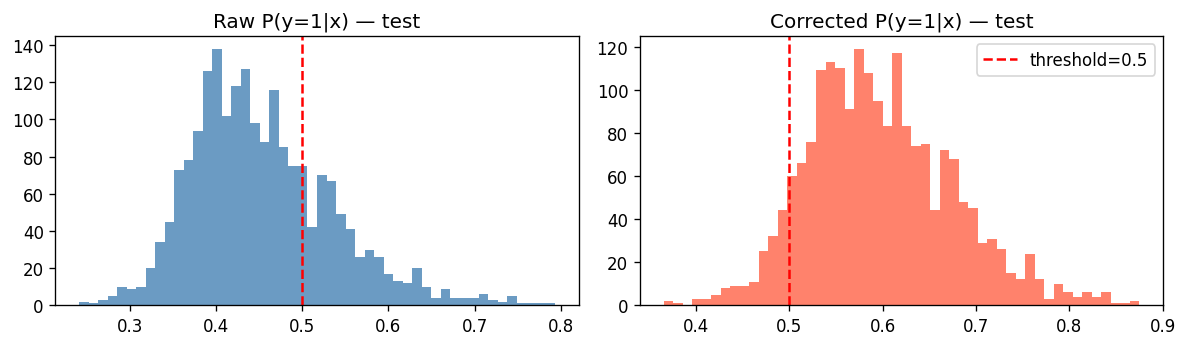

In [16]:
if test is not None:
    X_test = test_fe[best_tier_a]

    test_raw_p1  = champion_pipe_raw.predict_proba(X_test)[:, 1]

    # Prior correction
    odds_test    = test_raw_p1 / (1 - test_raw_p1 + eps)
    test_corr_p1 = (odds_test * CORRECTION) / (1 + odds_test * CORRECTION)
    test_binary  = (test_corr_p1 >= 0.5).astype(int)

    subfinal4 = pd.DataFrame({'id': test['id'], 'target': test_binary})
    if os.path.exists('sample_submission.csv'):
        ss = pd.read_csv('sample_submission.csv')
        subfinal4 = subfinal4[ss.columns]

    subfinal4.to_csv('subfinal4.csv', index=False)

    ratio1 = test_binary.mean()
    ratio_ok = '✓' if 0.40 < ratio1 < 0.57 else '⚠ 비율 이상'
    print(f'Saved: subfinal4.csv  ({len(subfinal4)}행)')
    print(f'예측 분포: 0={int((test_binary==0).sum())}  1={int((test_binary==1).sum())}')
    print(f'예측 1 비율: {ratio1:.4f}  (목표 ~{P_TEST_1:.3f})  {ratio_ok}')

    # 확률 분포 시각화
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(test_raw_p1, bins=50, color='steelblue', alpha=0.8)
    axes[0].axvline(0.5, color='red', linestyle='--')
    axes[0].set_title('Raw P(y=1|x) — test')
    axes[1].hist(test_corr_p1, bins=50, color='tomato', alpha=0.8)
    axes[1].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
    axes[1].set_title('Corrected P(y=1|x) — test')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('model4_prob_dist.png', bbox_inches='tight')
    plt.show()
else:
    print('test.csv 없음')

## 13. 최종 요약

In [17]:
print('=' * 68)
print('Model 4 — Prior Correction 완료')
print('=' * 68)
print(f'Prior correction factor : {CORRECTION:.4f}')
print(f'Effective raw threshold : {THRESH_RAW:.4f}  (= P_model > {THRESH_RAW:.3f} → predict 1)')
print(f'Champion                : {final_champ}')
print(f'OOF AUC                 : {oof_auc:.4f}')
print(f'OOF Acc                 : {oof_acc:.4f}')
print(f'OOF BalAcc              : {oof_bacc:.4f}')
if test is not None:
    print(f'Test 예측 1 비율        : {ratio1:.4f}  (목표 {P_TEST_1:.3f})')
print()
print('산출물:')
for f in ['answer4.csv', 'subfinal4.csv',
          'model4_strategy_compare.png', 'model4_prob_dist.png']:
    print(f'  [{"O" if os.path.exists(f) else "X"}] {f}')

Model 4 — Prior Correction 완료
Prior correction factor : 1.8228
Effective raw threshold : 0.3543  (= P_model > 0.354 → predict 1)
Champion                : Tuned lr(prior-corr)
OOF AUC                 : 0.6668
OOF Acc                 : 0.3671
OOF BalAcc              : 0.5080
Test 예측 1 비율        : 0.9175  (목표 0.488)

산출물:
  [O] answer4.csv
  [O] subfinal4.csv
  [O] model4_strategy_compare.png
  [O] model4_prob_dist.png
